### ⭐ Exercise 1 — "Vector Treasure Hunt" 🗺️
You start at the origin `(0, 0)`. Your pirate map gives directions as vectors:
"Walk `[3, 1]`, then `[1, 4]`, then `[-2, 2]`."
1. Where do you end up? (hint: add the vectors)
2. As the crow flies, how far is the treasure from your start? (hint: `np.linalg.norm`)
3. In what *unit-vector direction* should a bird fly straight to it?

Answer :We are given three vectors:
        [3,1], [1,4], and [−2,2]
        1. Final Position
            To find the final position, we add the vectors component-wise
              (3,1)+(1,4)+(−2,2)=(2,7)
              Final position = (2, 7)
        2.Distance from Origin
            The distance from the origin is the magnitude of the vector (2,7)
                Distance = √53 ≈ 7.28
        3.Unit Vector Direction
            The unit vector is obtained by dividing the vector by its magnitude            
            Unit vector ≈ (0.27, 0.96)
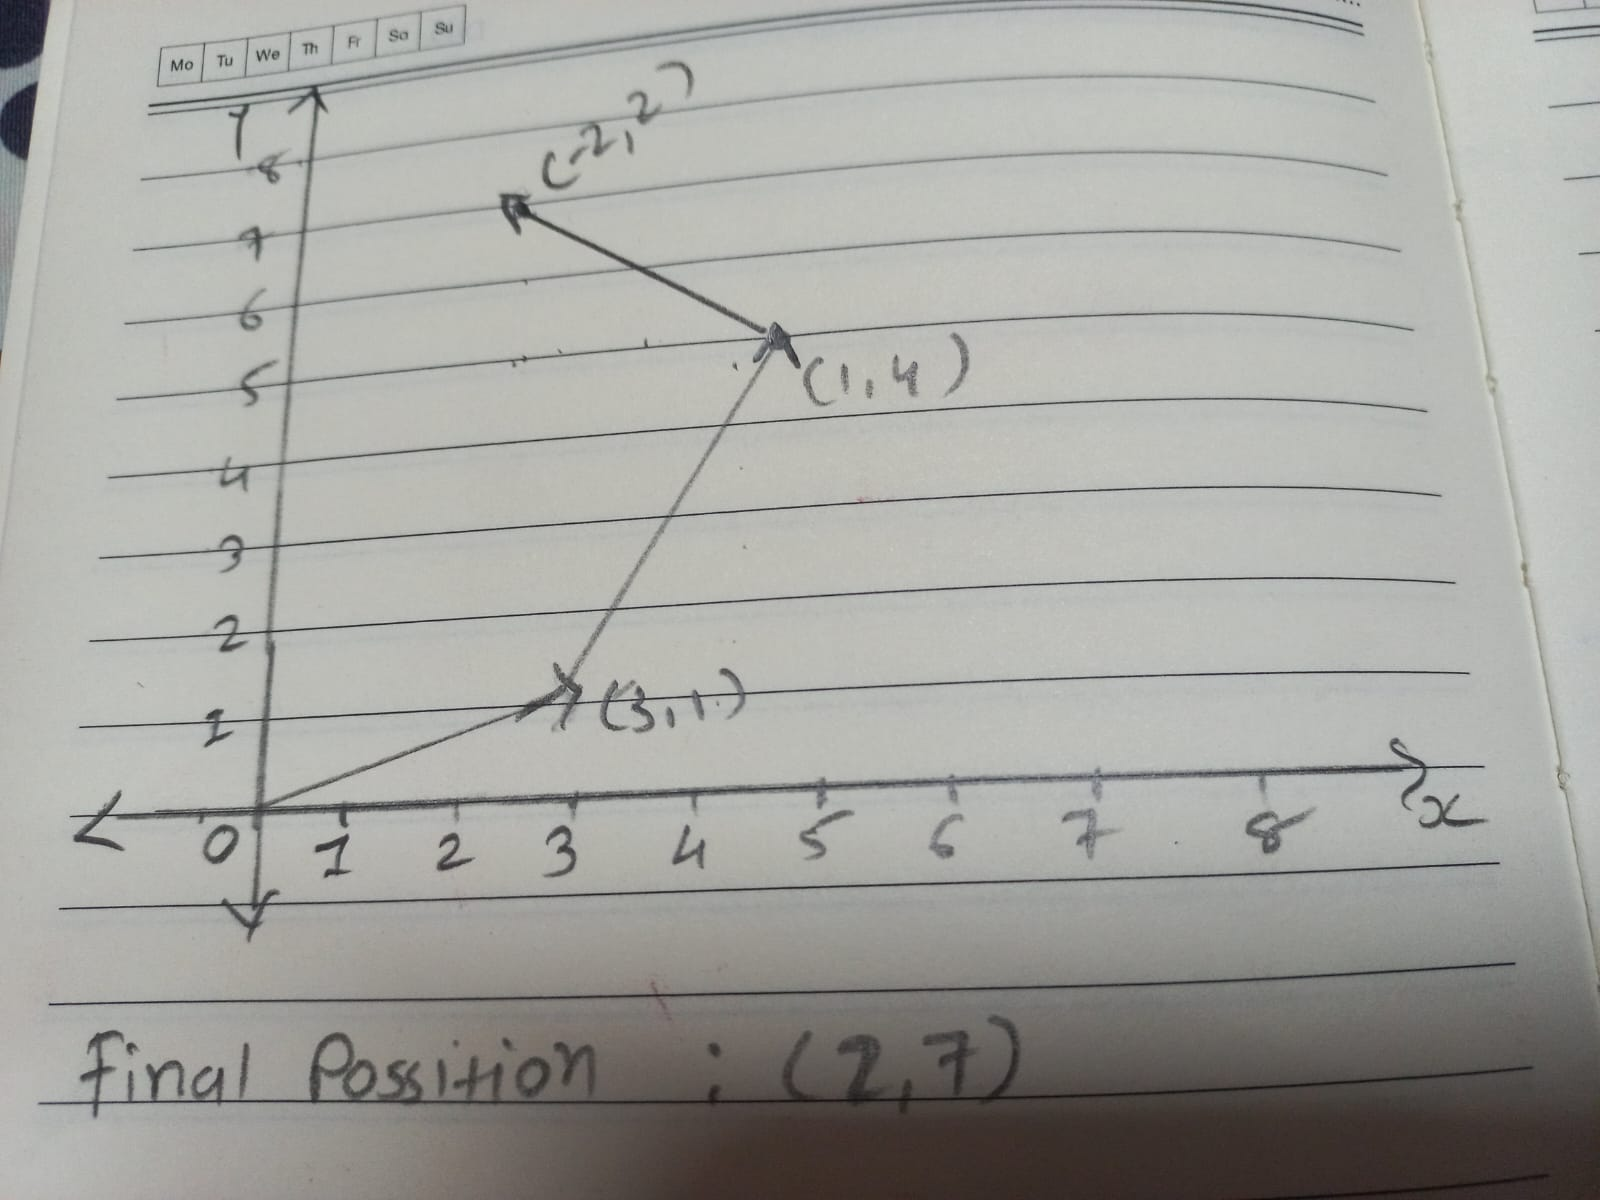

In [ ]:
import numpy as np

v1 = np.array([3, 1])
v2 = np.array([1, 4])
v3 = np.array([-2, 2])

#1. Where do you end up?
final_pos = v1 + v2 + v3
print("Final Position:", final_pos)

#2. As the crow flies, how far is the treasure from your start?
distance = np.linalg.norm(final_pos)
print("Distance:", distance)

#3. In what *unit-vector direction* should a bird fly straight to it?
unit_vector = final_pos / distance
print("Unit Vector:", unit_vector)


Final Position: [2 7]
Distance: 7.280109889280518
Unit Vector: [0.27472113 0.96152395]


### ⭐ Exercise 2 — "Movie Match-Maker" 🎬
Three users rated 4 movies (0–5). Use **cosine similarity** to find which two users have the
most similar taste — then recommend a movie one liked that the other hasn't seen.

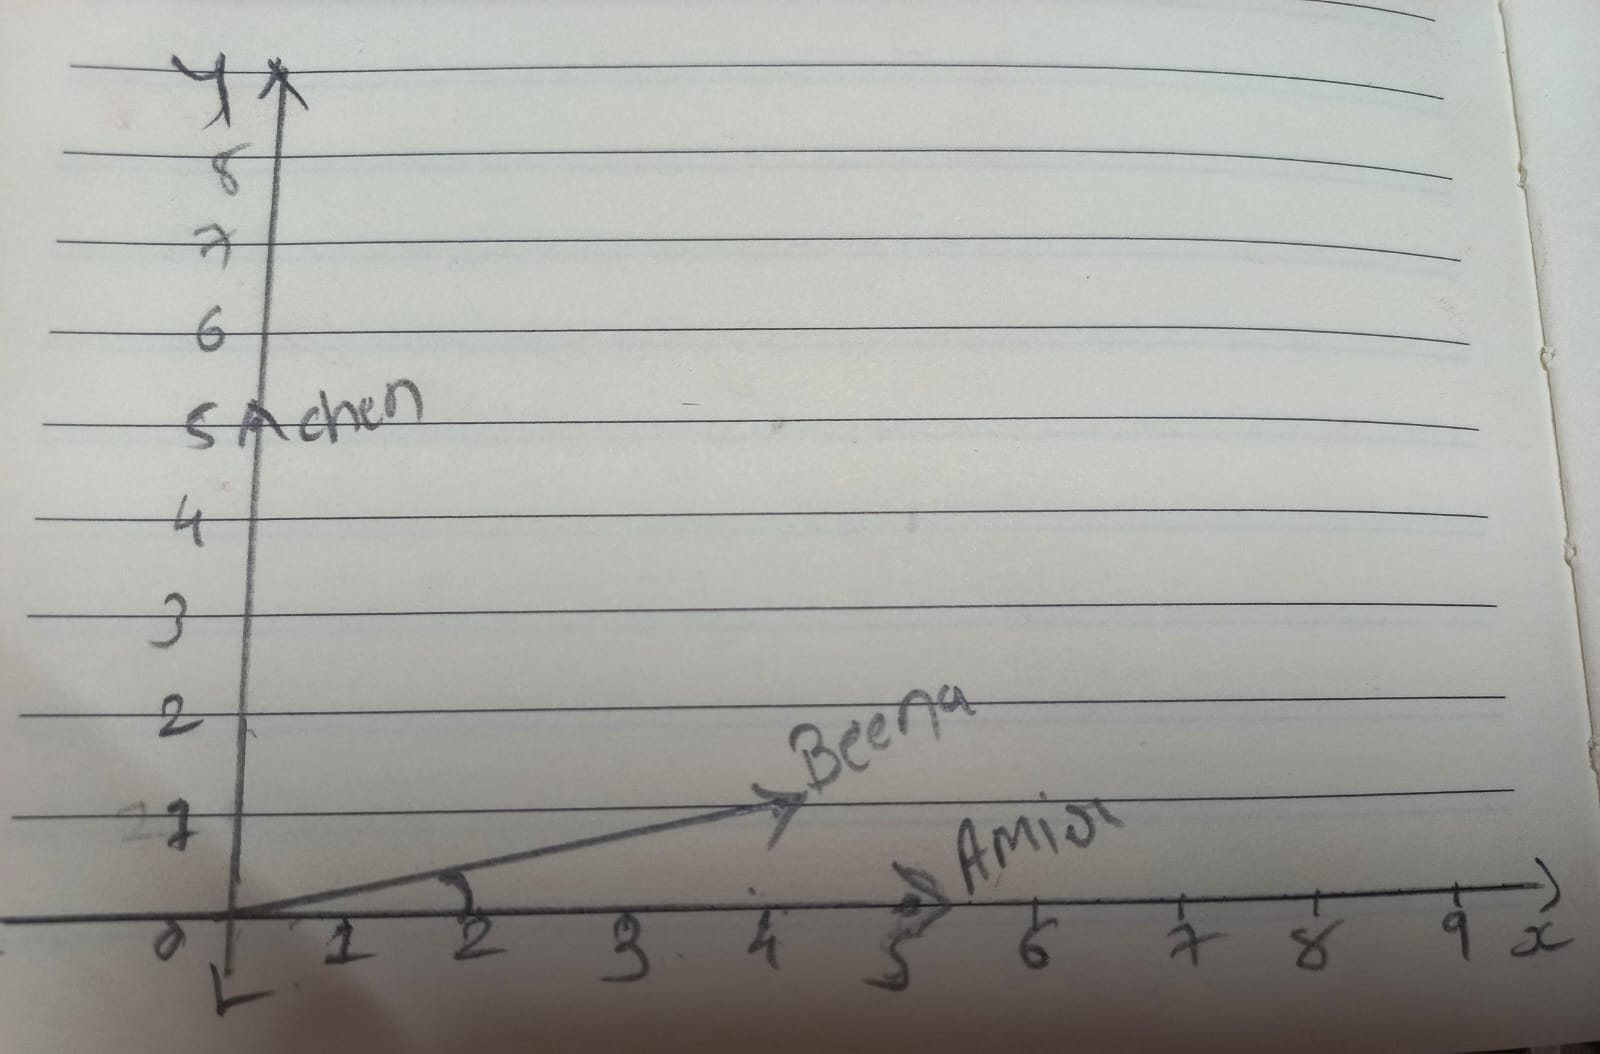

```python
amir  = np.array([5, 0, 4, 1])
beena = np.array([4, 1, 5, 0])
chen  = np.array([0, 5, 1, 4])
# Whose taste is closest? Build a 'recommend' suggestion from it.
```

Answer : np.dot(a, b) → measures how aligned the ratings are
         np.linalg.norm(a) → gives length of vector
         Cosine = angle similarity between users
         Higher value = more similar taste
         
         Amir–Beena ≈ 0.95 (highest)
         Amir–Chen ≈0.19
         Beena–Chen ≈0.238
         Most similar: Amir and Beena

         Recommendation
         Beena rated Movie 2, Amir rated 0 (not seen)

         Recommend Movie 2 to Amir


In [ ]:
import numpy as np

amir = np.array([5, 0, 4, 1])
beena = np.array([4, 1, 5, 0])
chen = np.array([0, 5, 1, 4])

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("Amir vs Beena:", round(cosine(amir, beena), 3))
print("Amir vs Chen:", round(cosine(amir, chen), 3))
print("Beena vs Chen:", round(cosine(beena, chen), 3))


Amir vs Beena: 0.952
Amir vs Chen: 0.19
Beena vs Chen: 0.238


### ⭐⭐ Exercise 3 — "Are You On My Side?" 🚧
Define a line `w = [2, -1], b = -1`. Generate 30 random 2-D points. Colour each point by which half-space it lands in (use the signed-distance function), and plot the line on top.
*Bonus:* circle the point closest to the line.

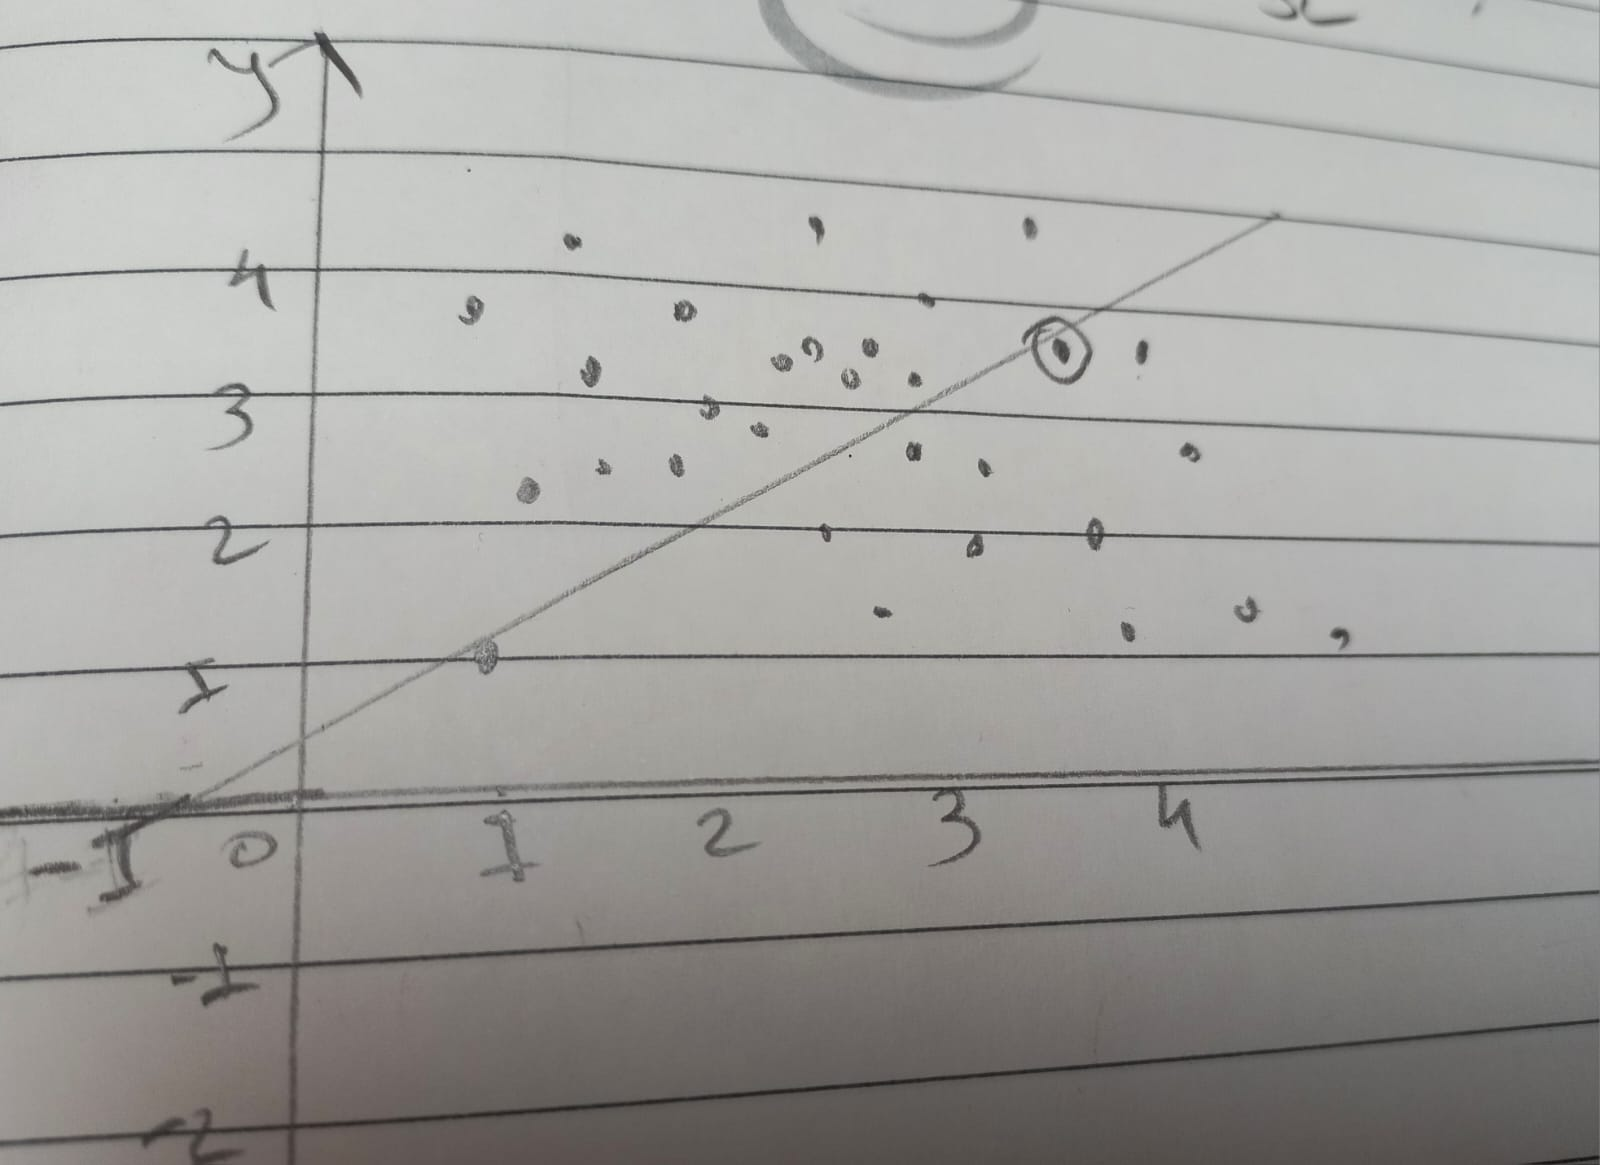

Answer: The line is defined by:
              w⋅x+b=0⇒2x−y−1=0

        For each point (x,y), compute:
                value=w⋅x+b=2x−y−1
        Classification:
            If value ≥ 0 → point lies on one side (colored green)
            If value < 0 → point lies on the other side (colored red)

        Visualization
            The points are plotted on a 2D graph using a scatter plot.
            The line y=2x−1 is plotted to divide the plane into two half-spaces.
            Each point is colored based on the sign of w⋅x+b.

        Bonus (Closest Point)

            The distance of a point from the line is proportional to:
                                              ∣w⋅x+b∣
            The point with the minimum absolute value is the closest to the line.
            This point is highlighted using a blue circle.


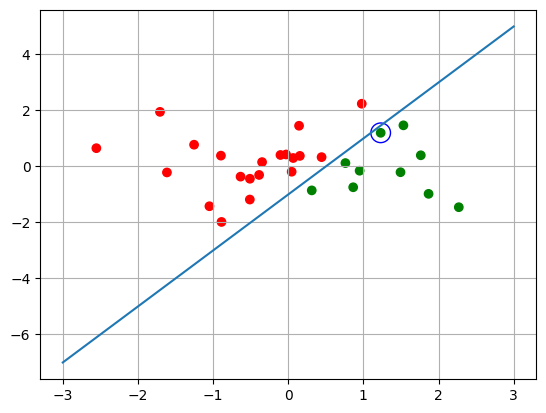

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Given line
w = np.array([2, -1])
b = -1

# 30 random points
np.random.seed(0)
points = np.random.randn(30, 2)

# signed value
values = np.dot(points, w) + b

# color points
colors = ['green' if v >= 0 else 'red' for v in values]

# plot points
plt.scatter(points[:,0], points[:,1], c=colors)

# plot line y = 2x - 1
x = np.linspace(-3, 3, 100)
y = 2*x - 1
plt.plot(x, y)

# BONUS: closest point
dist = np.abs(values)
idx = np.argmin(dist)

# circle closest point
plt.scatter(points[idx,0], points[idx,1],
            facecolors='none', edgecolors='blue', s=200)

plt.grid()
plt.show()

### ⭐⭐ Exercise 4 — "Shadow Puppets" 🔦
Pick any vector `a` and a direction `b`. Write a function that returns both the projection of `a`
onto `b` **and** the leftover *perpendicular* part `a - projection`. Verify the two pieces add back
to `a`, and that the perpendicular part really is perpendicular to `b` (its dot product with `b` ≈ 0).

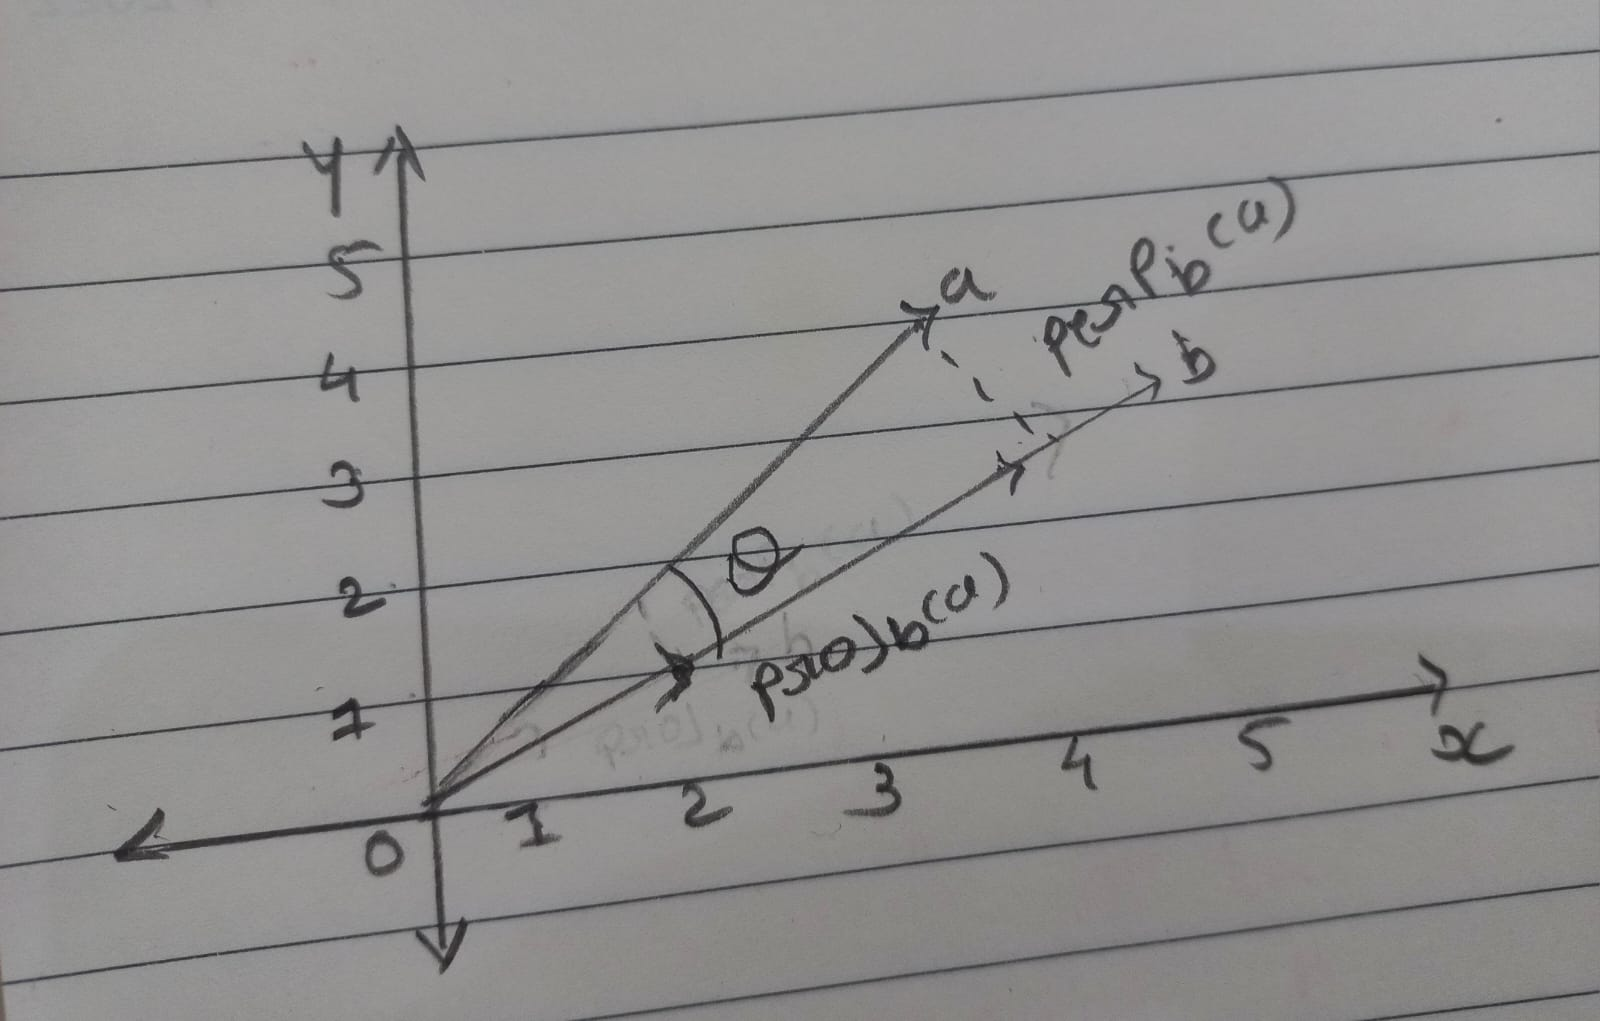

Answer:
Given

a = [3, 4]  
b = [2, 1]

---

### Projection Formula

$$
\text{Projection of } a \text{ onto } b = \frac{a \cdot b}{b \cdot b} \, b
$$

---

### Step 1: Dot Products

$$
a \cdot b = 3 \times 2 + 4 \times 1 = 10
$$

$$
b \cdot b = 2 \times 2 + 1 \times 1 = 5
$$

---

### Step 2: Projection

$$
\text{Projection} = \frac{10}{5} \times [2,1] = 2 \times [2,1] = [4,2]
$$

---

### Step 3: Perpendicular Part

$$
\text{Perpendicular} = a - \text{Projection}
$$

$$
= [3,4] - [4,2] = [-1,2]
$$

---

### Step 4: Verification

$$
[4,2] + [-1,2] = [3,4]
$$

$$
[-1,2] \cdot [2,1] = -2 + 2 = 0
$$

---

### Final Answer

Projection = [4, 2]  
Perpendicular = [-1, 2]




Projection = [4, 2]
Perpendicular = [-1, 2]
Add back = original vector ✅
Dot product = 0 → perfectly perpendicular ✅


In [ ]:
import numpy as np

def shadow_puppets(a, b):
    # Projection of a onto b
    projection = (np.dot(a, b) / np.dot(b, b)) * b

    # Perpendicular part
    perpendicular = a - projection

    return projection, perpendicular


# Given values
a = np.array([3, 4])
b = np.array([2, 1])

# Function call
proj, perp = shadow_puppets(a, b)

# Output
print("Vector a:", a)
print("Vector b:", b)

print("\nProjection of a onto b:", proj)
print("Perpendicular part:", perp)

# Verification
print("\nCheck 1 (Reconstruction a):", proj + perp)
print("Original a:", a)

print("\nCheck 2 (Dot product with b):", np.dot(perp, b))

Vector a: [3 4]
Vector b: [2 1]

Projection of a onto b: [4. 2.]
Perpendicular part: [-1.  2.]

Check 1 (Reconstruction a): [3. 4.]
Original a: [3 4]

Check 2 (Dot product with b): 0.0


### ⭐⭐ Exercise 5 — "Build a 2-Line Classifier" 🤖
You're given two clusters of points (make them up, e.g. one around `(1,1)`, one around `(5,5)`).
**By hand**, choose a `w` and `b` so the line `w·x + b = 0` separates them. Plot it. How few points
can you misclassify? (This is what training a model automates — you're doing it manually!)

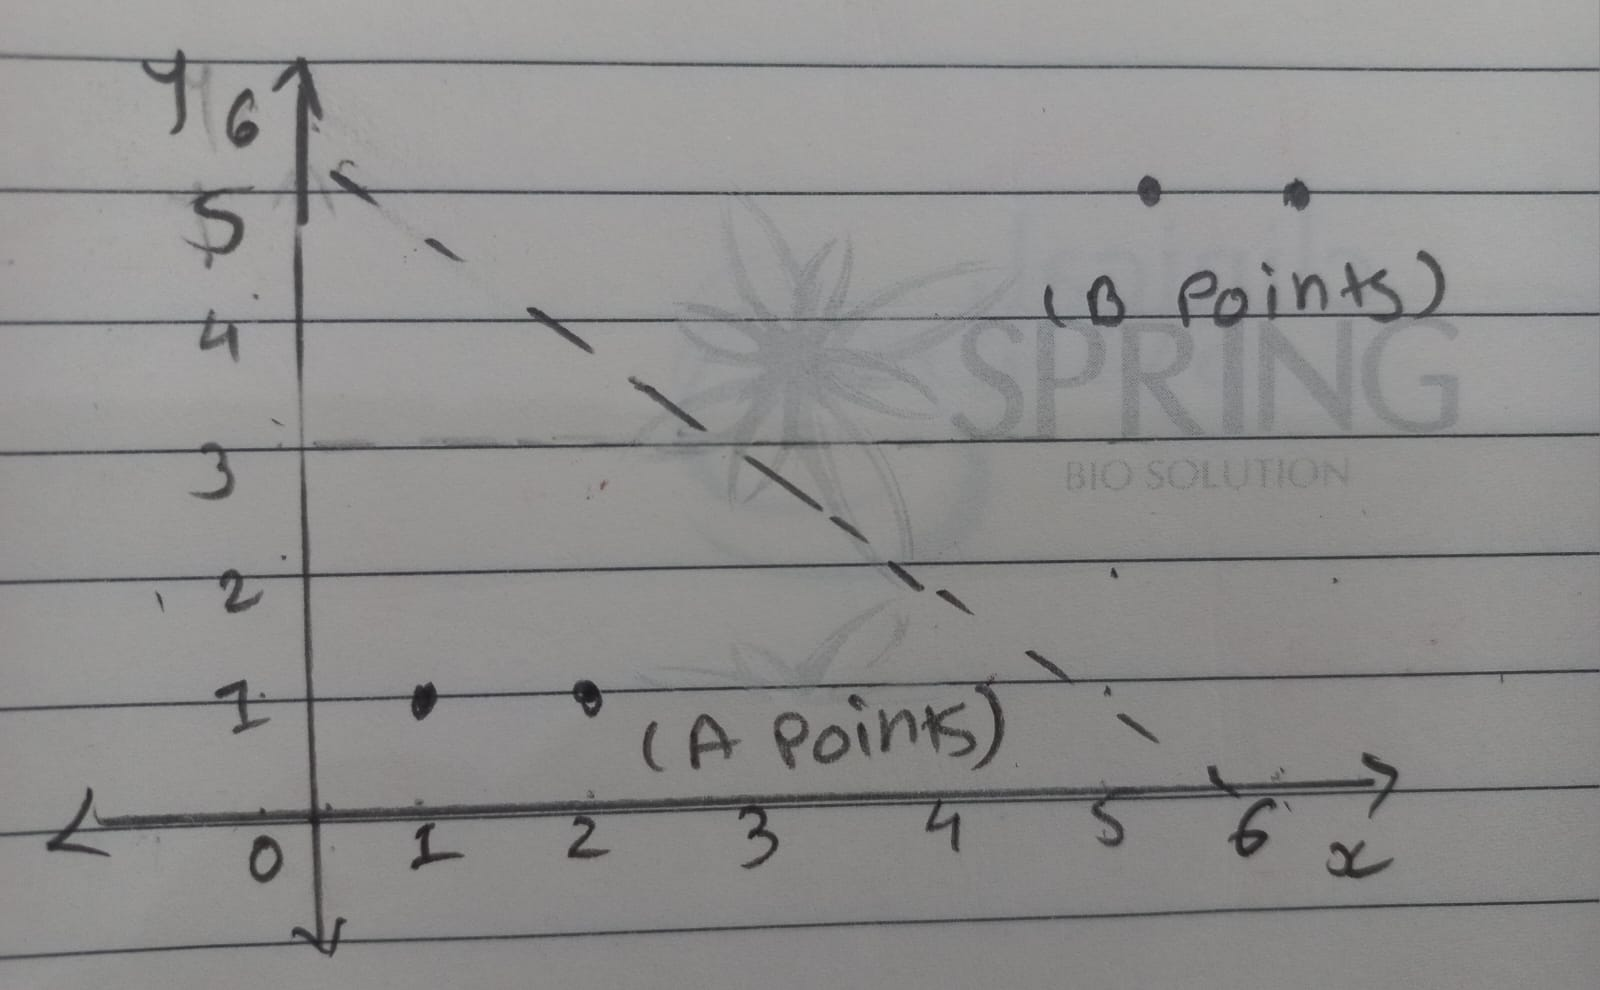

Answer :

Given:

Cluster A (near (1,1)):  
(1,1), (2,1)

Cluster B (near (5,5)):  
(5,5), (6,5)

---

### Decision Boundary

We choose:

$$
w = [1,1], \quad b = -6
$$

So the equation becomes:

$$
w \cdot x + b = 0
$$

$$
x + y - 6 = 0
$$

---

### Checking Points

For Cluster A:

$$
(1,1): 1+1-6 = -4
$$

$$
(2,1): 2+1-6 = -3
$$

(All negative → one side)

---

For Cluster B:

$$
(5,5): 5+5-6 = 4
$$

$$
(6,5): 6+5-6 = 5
$$

(All positive → other side)

---

### Misclassification

All points are correctly classified.

$$
\text{Misclassified points} = 0
$$

---

### Final Answer

- Decision boundary: $$x + y - 6 = 0$$  
- w = [1,1], b = -6  
- Misclassification = 0  


Predictions: [-1 -1  1  1]
Actual: [-1 -1  1  1]
Misclassified points: 0


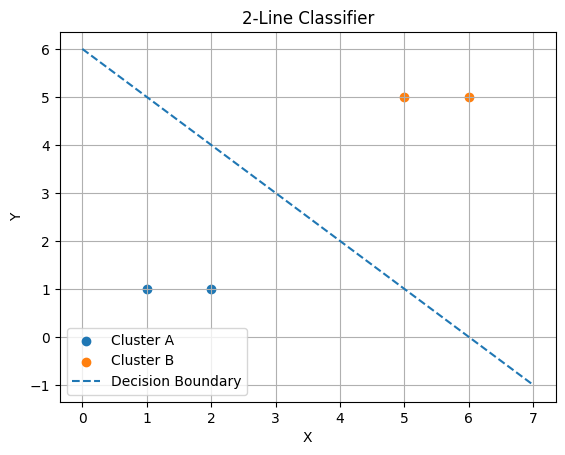

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cluster A (label -1)
A = np.array([[1,1], [2,1]])

# Cluster B (label +1)
B = np.array([[5,5], [6,5]])

# Combine data
X = np.vstack((A, B))
y = np.array([-1, -1, 1, 1])  # labels

# Define w and b
w = np.array([1,1])
b = -6

# Function for prediction
def predict(x):
    return np.sign(np.dot(w, x) + b)

# Predictions
predictions = np.array([predict(x) for x in X])

# Count misclassified
misclassified = np.sum(predictions != y)

print("Predictions:", predictions)
print("Actual:", y)
print("Misclassified points:", misclassified)

# Plot points
plt.scatter(A[:,0], A[:,1], label='Cluster A')
plt.scatter(B[:,0], B[:,1], label='Cluster B')

# Decision boundary: x + y = 6 → y = 6 - x
x_vals = np.linspace(0,7,100)
y_vals = 6 - x_vals

plt.plot(x_vals, y_vals, linestyle='--', label='Decision Boundary')

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title("2-Line Classifier")

plt.grid()
plt.show()

### ⭐⭐⭐ Exercise 6 — "Curse-Breaker Investigation" 🕵️
Recreate the curse-of-dimensionality experiment, but this time also plot the **average** distance
between random points as dimensions grow. Then try **normalizing** the distances by `sqrt(dim)` and
see if the picture changes. Write 2–3 sentences explaining to a friend why KNN struggles in 1000-D.

Answer: Observation:
      As dimension increases → average distance increases
      After normalization → values become almost constant

      In high-dimensional spaces, distances between points increase but also become very similar to each other. This makes it difficult to distinguish between nearest and farthest neighbors. As a result, KNN struggles in 1000-D because all points appear almost equally distant, reducing its effectiveness.

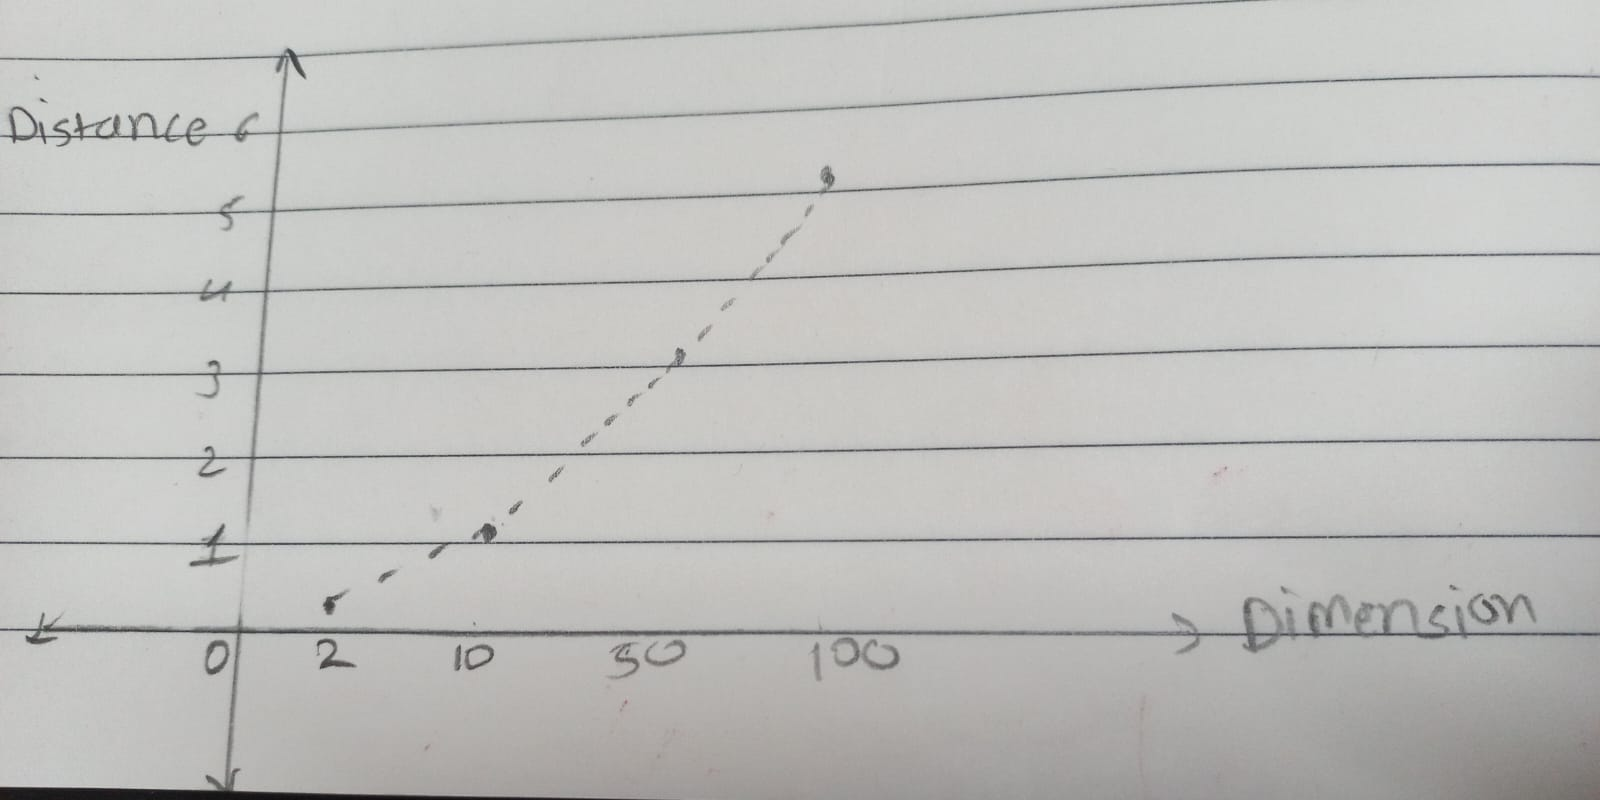


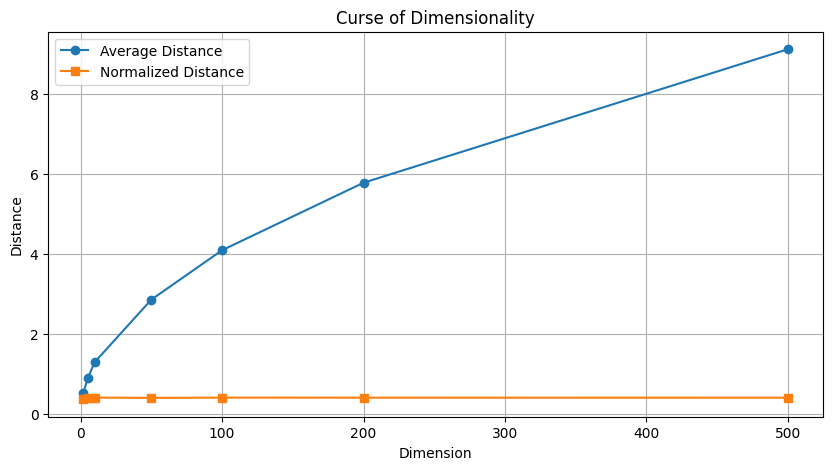

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# different dimensions
dimensions = [2, 5, 10, 50, 100, 200, 500]

avg_distances = []
normalized_distances = []

n_points = 100  # number of random points

for d in dimensions:
    # Step 1: generate random points
    points = np.random.rand(n_points, d)

    distances = []

    # Step 2: compute pairwise distances
    for i in range(n_points):
        for j in range(i+1, n_points):
            dist = np.linalg.norm(points[i] - points[j])
            distances.append(dist)

    distances = np.array(distances)

    # Step 3: average distance
    avg_distances.append(np.mean(distances))

    # Step 4: normalized distance
    normalized_distances.append(np.mean(distances / np.sqrt(d)))

# Step 5: Plot
plt.figure(figsize=(10,5))

plt.plot(dimensions, avg_distances, marker='o', label="Average Distance")
plt.plot(dimensions, normalized_distances, marker='s', label="Normalized Distance")

plt.xlabel("Dimension")
plt.ylabel("Distance")
plt.title("Curse of Dimensionality")
plt.legend()
plt.grid()

plt.show()

### ⭐⭐⭐ Exercise 7 — "Draw Your Own Galaxy" 🌌
Generate 200 points sampled from a **tilted ellipse** (hint: scale a circle by different `a`, `b`,
then rotate using a 2×2 rotation matrix). Plot them. Congratulations — you've just generated
*correlated data*, exactly what real datasets look like. (Optional: find the ellipse's long axis —
that's the first principal component!)

Answer:  The points form a tilted elliptical shape. This shows that the data is
          correlated and not random.
          
          This exercise generates structured data similar to real-world datasets. The tilted ellipse represents correlation between variables.

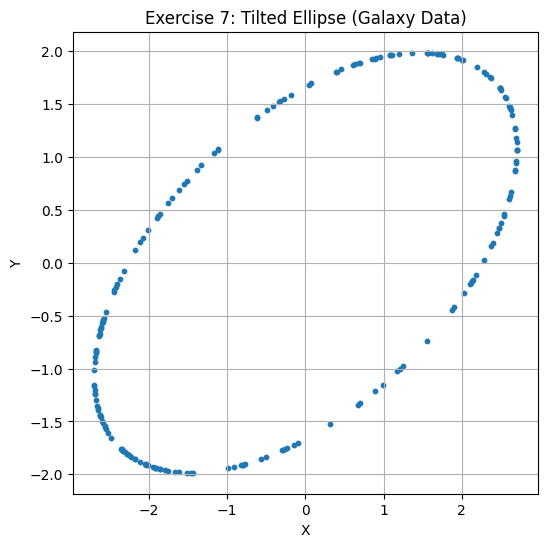

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: generate circle points
n = 200
theta = np.random.uniform(0, 2*np.pi, n)
circle = np.array([np.cos(theta), np.sin(theta)])

# Step 2: make ellipse (scale x and y)
a = 3   # x stretch
b = 1.5 # y stretch
ellipse = np.array([a * circle[0], b * circle[1]])

# Step 3: rotation matrix (tilt)
angle = np.pi / 6   # 30 degrees

R = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle),  np.cos(angle)]
])

tilted = R @ ellipse

# Step 4: plot
plt.figure(figsize=(6,6))
plt.scatter(tilted[0], tilted[1], s=10)

plt.title("Exercise 7: Tilted Ellipse (Galaxy Data)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.show()